0.3947299951571677


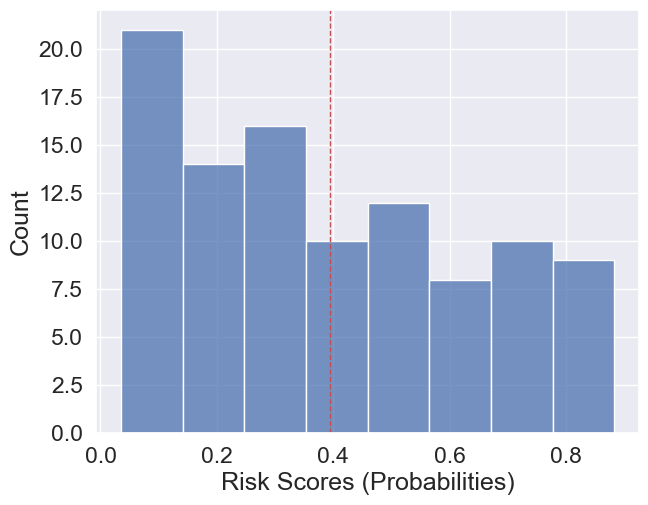

In [46]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from interpret.glassbox import ExplainableBoostingClassifier
df_test=pd.read_csv('.../PycharmProjects/RedditRiskPrediction/data/datasets/hillaryclinton.csv', index_col=False, skiprows=0)
X_test=df_test.iloc[:,:]


df_train=pd.read_csv('.../PycharmProjects/social_media_risk_scores/data/folds/training_final.csv', index_col=False)
df_train=df_train.dropna()

X_train=df_train.iloc[:,4:]
y_train=df_train.label_train.values

ebm = ExplainableBoostingClassifier(inner_bags=100, outer_bags=10,max_bins=32, max_leaves=2)
ebm.fit(X_train,y_train)


scores= ebm.predict_proba(X_test)[:, 1]
#scores.sort()
print(np.mean(scores[:]))
#print(X_test.iloc[10,:])
import seaborn as sns
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.set(style="darkgrid")
sns.set(font_scale = 1.5)
g= sns.histplot(data=scores[:100])
#g= sns.histplot(data=scores)
#sns.set(rc={'figure.figsize':(11.7,11.7)})
g.set(xlabel='Risk Scores (Probabilities)')
#g.tick_params(labelsize=13)
plt.axvline(np.mean(scores[:100]), color='r', linestyle='dashed', linewidth=1)

plt.savefig(".../Desktop/hillary_hist.pdf",dpi=300)


In [38]:
import pandas as pd

df=pd.read_csv('.../PycharmProjects/social_media_risk_scores/data/folds/training_final.csv', index_col=False)
df2=pd.read_csv('.../PycharmProjects/social_media_risk_scores/data/folds/testing_final.csv', index_col=False)
df=df.dropna()
#df = df.loc[df['Author'].isin(authors)]
df2 = df2.loc[df2['Author'].isin(df.Author)]

X=df.iloc[:,4:]
y=df.label_train.values

X2 = df2.iloc[:, 4:]
y2= df2.label_train.values

X_train, X_, y_train, y_ = train_test_split(X, y, test_size=0.2, random_state=6)
X_, X_test, y_, y_test = train_test_split(X2, y2, test_size=0.2,random_state=6)

In [3]:
import pandas as pd
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, average_precision_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV, KFold
import itertools as it
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb 
ebm= xgb.XGBClassifier(tree_method="hist", max_depth=3, min_child_weight=6, gamma=0.8)
ebm.fit(X_train, y_train)
print(accuracy_score(y_test, ebm.predict(X_test)))
print(precision_score(y_test, ebm.predict(X_test)))
print(recall_score(y_test, ebm.predict(X_test)))
print(roc_auc_score(y_test, ebm.predict(X_test)))
print(f1_score(y_test, ebm.predict(X_test)))

NameError: name 'X_train' is not defined

In [46]:
ebm = RandomForestClassifier(random_state=6,bootstrap=True, max_features=None, n_estimators=150, class_weight=None)
ebm.fit(X_train, y_train)
print(accuracy_score(y_test, ebm.predict(X_test)))
print(precision_score(y_test, ebm.predict(X_test)))
print(recall_score(y_test, ebm.predict(X_test)))
print(roc_auc_score(y_test, ebm.predict(X_test)))
print(f1_score(y_test, ebm.predict(X_test)))

0.7794117647058824
0.5673758865248227
0.7339449541284404
0.7649657881010096
0.6400000000000001


In [115]:
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show
ebm = ExplainableBoostingClassifier(inner_bags=100, outer_bags=10, max_bins=32, max_leaves=2)
ebm.fit(X_train, y_train)
print(accuracy_score(y_test, ebm.predict(X_test)))
print(precision_score(y_test, ebm.predict(X_test)))
print(recall_score(y_test, ebm.predict(X_test)))
print(roc_auc_score(y_test, ebm.predict(X_test)))
print(f1_score(y_test, ebm.predict(X_test)))

0.8186274509803921
0.6223776223776224
0.8165137614678899
0.8179558773894633
0.7063492063492065


In [48]:
ebm= LogisticRegression(penalty='l1',solver='saga')
ebm.fit(X_train, y_train)
print(accuracy_score(y_test, ebm.predict(X_test)))
print(precision_score(y_test, ebm.predict(X_test)))
print(recall_score(y_test, ebm.predict(X_test)))
print(roc_auc_score(y_test, ebm.predict(X_test)))
print(f1_score(y_test, ebm.predict(X_test)))

0.803921568627451
0.6090225563909775
0.7431192660550459
0.7846031112883926
0.6694214876033058


/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:352: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



In [746]:
ebm_global = ebm.explain_global(name='EBM')
show(ebm_global)

<!-- http://127.0.0.1:7001/140690793302576/ -->

In [27]:
import random
df=pd.read_csv('.../PycharmProjects/social_media_risk_scores/data/folds/training_final.csv', index_col=False)
df2=pd.read_csv('.../PycharmProjects/social_media_risk_scores/data/folds/testing_final.csv', index_col=False)
df=df.dropna()
#df = df.loc[df['Author'].isin(authors)]
df2 = df2.loc[df2['Author'].isin(df.Author)]



x1 = df.loc[df['label_train'] == 0].index.values
x2 = df.loc[df['label_train'] == 0].index.values
x3 = list(set(x1).intersection(x2))
indices=[]
for i in range(len(x3)):
    if x3[i]<1000:
        indices.append(x3[i])

#random.seed(6)       
#samples=random.sample(indices,0)
#df=df.drop(index=samples)
#df2 = df2.loc[df2['Author'].isin(df.Author)]

print(len(df))


X=df.iloc[:,4:]
y=df.label_train.values

X2 = df2.iloc[:, 4:]
y2= df2.label_train.values


X_train, X_, y_train, y_ = train_test_split(X, y, test_size=0.2, random_state=6)
X_, X_test, y_, y_test = train_test_split(X2, y2, test_size=0.2,random_state=6)

from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show
ebm = ExplainableBoostingClassifier(inner_bags=100, outer_bags=10, max_bins=32, max_leaves=2)
ebm.fit(X_train, y_train)
print(accuracy_score(y_test, ebm.predict(X_test)))
print(precision_score(y_test, ebm.predict(X_test)))
print(recall_score(y_test, ebm.predict(X_test)))
print(roc_auc_score(y_test, ebm.predict(X_test)))
print(f1_score(y_test, ebm.predict(X_test)))

ebm_global = ebm.explain_global(name='EBM')
show(ebm_global)

2037
0.8186274509803921
0.6223776223776224
0.8165137614678899
0.8179558773894633
0.7063492063492065


<!-- http://127.0.0.1:7561/140346780950048/ -->

In [16]:
from scipy import stats
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show
import pandas as pd
import numpy as np
df2=pd.read_csv('.../PycharmProjects/social_media_risk_scores/data/folds/training_final.csv', index_col=False)
df2=df2.dropna()

mean1=[]
mean2=[]
sd1=[]
sd2=[]

X_train=df2.iloc[:,4:]
y_train=df2.label_train.values

ebm = ExplainableBoostingClassifier(inner_bags=100, outer_bags=10, max_bins=32, max_leaves=3)
ebm.fit(X_train, y_train)

for fold in range(3,8):
    df=pd.read_csv('.../PycharmProjects/social_media_risk_scores/data/folds/training_fold'+str(fold)+'.csv', index_col=False)
    df=df.dropna()


    df3 = df.loc[df['label'] == 1]
    df4 = df.loc[df['label'] == 0]



    X_test1 = df4.iloc[:, 4:]
    y_test1= df4.label_train.values
    
    X_test2 = df3.iloc[:, 4:]
    y_test2= df3.label_train.values




    scores1= ebm.predict_proba(X_test1)[:, 1]
    scores2= ebm.predict_proba(X_test2)[:, 1]
    
    mean1.append(np.mean(scores1[:]))
    sd1.append(np.std(scores1[:]))
    mean2.append(np.mean(scores2[:]))
    sd2.append(np.std(scores2[:]))


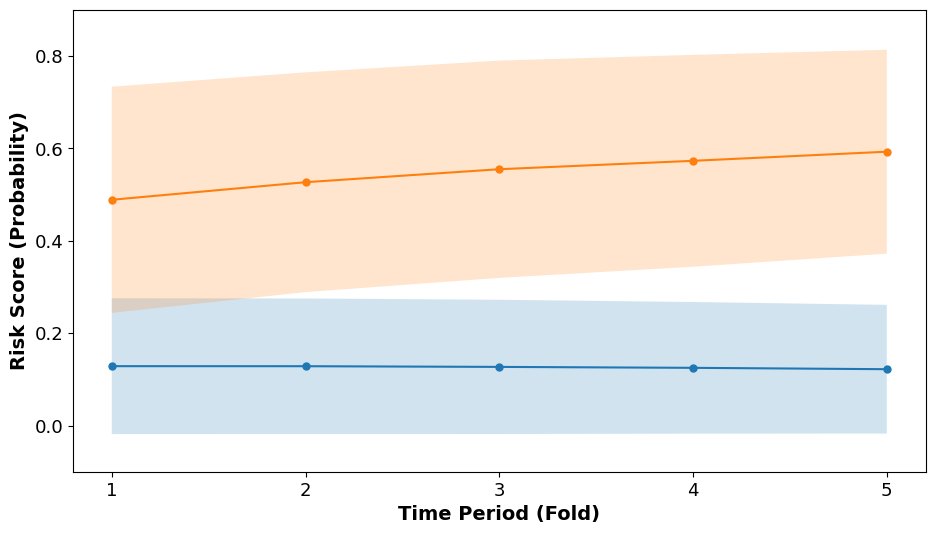

In [17]:
from matplotlib import pyplot as plt
mean1=np.asarray(mean1)

mean2=np.asarray(mean2)
sd1=np.asarray(sd1)

sd2=np.asarray(sd2)

#error = sd * 0.5
lower1 = mean1 - (sd1)
upper1 = mean1 + (sd1)

lower2 = mean2 - (sd2)
upper2 = mean2 + (sd2)
x=[1,2,3,4,5]

fig = plt.figure(figsize=(11, 6))

plt.plot(x, mean1,marker='o',markersize=5)
plt.fill_between(x, lower1, upper1, alpha=0.2)
plt.plot(x, mean2, marker='o',markersize=5)
plt.fill_between(x, lower2, upper2, alpha=0.2)
plt.xticks(np.arange(min(x), max(x)+1, 1.0),fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel('Time Period (Fold)',fontsize=14,fontdict=dict(weight='bold'))
plt.ylabel('Risk Score (Probability)',fontsize=14,fontdict=dict(weight='bold'))
plt.ylim((-0.1,0.9))
#plt.show()
plt.savefig(".../Desktop/risk_probs_time.pdf",dpi=300)

In [2]:
import random
import pandas as pd
import numpy as np
from interpret.glassbox import ExplainableBoostingClassifier
from sklearn.model_selection import train_test_split
importances=[]

for fold in range(3,8): 
    df=pd.read_csv('.../PycharmProjects/social_media_risk_scores/data/folds/training_fold'+str(fold)+'.csv', index_col=False)
    df=df.dropna()    

    
    X=df.iloc[:,4:]
    y=df.label_train.values

    X_train, X_, y_train, y_ = train_test_split(X, y, test_size=0.2, random_state=6)
    
    ebm = ExplainableBoostingClassifier(inner_bags=100, outer_bags=10,max_bins=32, max_leaves=2)
    ebm.fit(X_train, y_train)
    importance = ebm.term_importances(importance_type='avg_weight')
    importances.append(importance)

importances=np.asarray(importances)



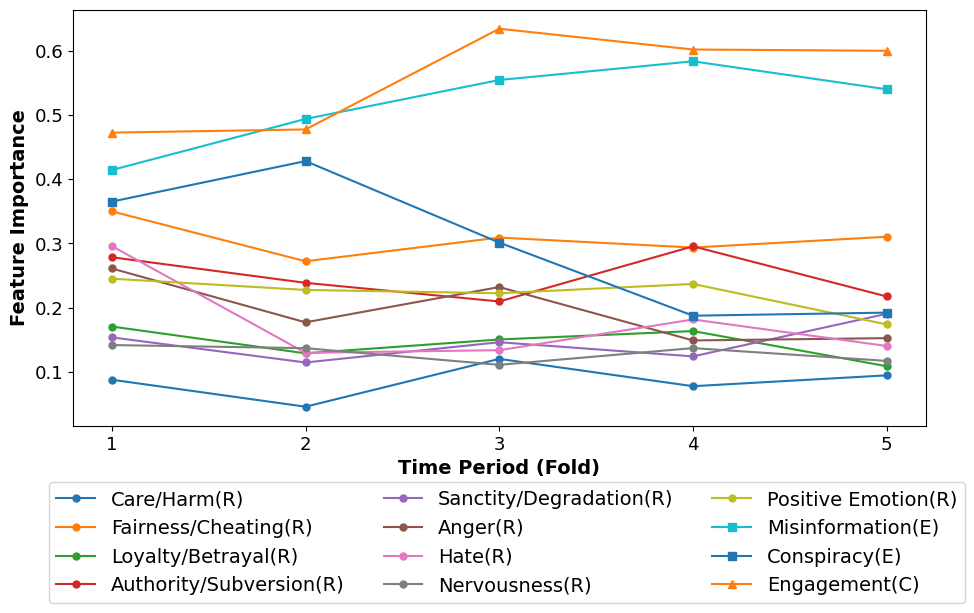

In [13]:
from matplotlib import pyplot as plt

x=[1,2,3,4,5]
labels=["Care/Harm(R)","Fairness/Cheating(R)","Loyalty/Betrayal(R)","Authority/Subversion(R)","Sanctity/Degradation(R)","Anger(R)","Hate(R)","Nervousness(R)","Positive Emotion(R)", "Misinformation(E)","Conspiracy(E)","Engagement(C)"]
fig = plt.figure(figsize=(11, 6))
ax = plt.subplot(111)
for i,imp in enumerate(importances.T[:12]):
    if i<9:
        ax.plot(x, imp,marker='o',markersize=5, label=labels[i])
    elif i==11:
        ax.plot(x, imp, marker='^', label=labels[i])
    elif (i>=9 & i<11):
        ax.plot(x, imp,marker='s', label=labels[i])

ax.set_xticks(np.arange(min(x), max(x)+1, 1.0),fontsize=13)
ax.tick_params(labelsize=13)
ax.set_xlabel('Time Period (Fold)',fontsize=14,fontdict=dict(weight='bold'))
box = ax.get_position()
ax.set_position([box.x0, box.y0 + box.height * 0.1,
                 box.width, box.height * 0.9])

# Put a legend below current axis
ax.legend(loc='lower left', bbox_to_anchor=(-0.04, -0.45),
          fancybox=True, shadow=False, ncol=3,prop={'size': 14})

ax.set_ylabel('Feature Importance',fontsize=14,fontdict=dict(weight='bold'))
fig.savefig(".../Desktop/importance_overtime.pdf",bbox_inches='tight',dpi=300)

In [19]:
import random
import pandas as pd
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show
df=pd.read_csv('.../social_media_risk_scores/data/folds/training_final.csv', index_col=False)
df=df.dropna()

X=df.iloc[:,4:]
y=df.label_train.values

X_train, X_, y_train, y_ = train_test_split(X, y, test_size=0.2,  random_state=6)

ebm = ExplainableBoostingClassifier(inner_bags=100, outer_bags=10,max_bins=32, max_leaves=2)
ebm.fit(X_train,y_train)

ebm_global = ebm.explain_global(name='EBM')
show(ebm_global)

<!-- http://127.0.0.1:7001/140198625853744/ -->

In [22]:
fig= ebm_global.visualize()
fig.update_layout(font=dict( 
        size=18,
    color="black"
    ))
fig.write_image(".../Desktop/all_term.pdf", width=1000, height=600 )

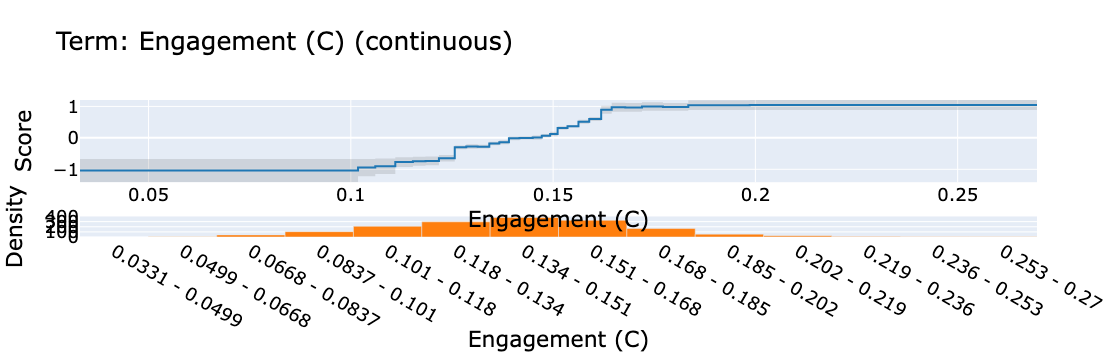

In [23]:
fig= ebm_global.visualize(key=11)
fig.update_layout(font=dict( 
        size=18,
    color="black"
    ))